
# Chapter 5 Companion Notebook  
## Tail Risk in Discrete Newsvendor Models: VaR, TCE, and CVaR

This notebook is the Python companion for **Chapter 5** of *Risk Analytics*.

It is designed to do four things:

1. reproduce the main **discrete VaR, TCE, and exact CVaR** calculations from the chapter,
2. implement the **binomial-demand** newsvendor example,
3. implement the **Poisson-demand** newsvendor example,
4. reproduce the chapter-style **sensitivity analysis** in the parameters \(\lambda\) and \(\alpha\).

The notebook follows the notation of the chapter:
- $Q$: order quantity,
- $D$: discrete demand,
- $L(Q,D)$: induced loss,
- $\mathrm{VaR}_\alpha$: Value at Risk,
- $\mathrm{TCE}_\alpha$: Tail Conditional Expectation,
- $\mathrm{CVaR}_\alpha$: exact discrete Conditional Value at Risk.

Run the notebook from top to bottom.



## 0. Imports and plotting style

This cell loads the packages used throughout the notebook and defines a small set of helper functions used across sections.


In [8]:

import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from textwrap import dedent

from scipy.stats import binom, poisson

plt.rcParams["figure.figsize"] = (8, 4.8)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["lines.linewidth"] = 2

FIG_DIR = Path("figures/chapter_5")
FIG_DIR.mkdir(parents=True, exist_ok=True)



## 1. Generic discrete VaR, TCE, and exact CVaR

Chapter 5 emphasizes that in discrete models:

- $\mathrm{VaR}_\alpha$ is the smallest loss threshold whose cumulative probability reaches $\alpha$,
- $\mathrm{TCE}_\alpha$ averages all loss realizations at or above the VaR threshold,
- exact discrete $\mathrm{CVaR}_\alpha$ averages the worst exactly $1-\alpha$ probability mass.

The difference between TCE and exact CVaR matters only because the discrete distribution may place positive probability mass at the VaR point.

from IPython.display import Markdown, display


### 1A. Helper functions for discrete tail risk

In [2]:

def discrete_var(losses, probs, alpha):
    """Exact discrete VaR from an arbitrary finite support."""
    losses = np.asarray(losses, dtype=float)
    probs = np.asarray(probs, dtype=float)
    order = np.argsort(losses)
    L = losses[order]
    p = probs[order]
    cdf = np.cumsum(p)
    idx = np.where(cdf >= alpha)[0][0]
    return float(L[idx])


def discrete_tce(losses, probs, alpha):
    """TCE = E[L | L >= VaR_alpha(L)]."""
    losses = np.asarray(losses, dtype=float)
    probs = np.asarray(probs, dtype=float)
    var = discrete_var(losses, probs, alpha)
    mask = losses >= var
    return float(np.sum(losses[mask] * probs[mask]) / np.sum(probs[mask]))


def discrete_cvar(losses, probs, alpha):
    """Exact discrete CVaR over the worst exactly 1-alpha probability mass."""
    losses = np.asarray(losses, dtype=float)
    probs = np.asarray(probs, dtype=float)
    order = np.argsort(losses)
    L = losses[order]
    p = probs[order]
    cdf = np.cumsum(p)
    idx = np.where(cdf >= alpha)[0][0]
    var = float(L[idx])
    Fvar = float(cdf[idx])

    above = L > var
    tail_sum = np.sum(L[above] * p[above])
    cvar = (tail_sum + var * (Fvar - alpha)) / (1 - alpha)
    return float(cvar)


def summarize_discrete_tail(losses, probs, alpha):
    return {
        "VaR": discrete_var(losses, probs, alpha),
        "TCE": discrete_tce(losses, probs, alpha),
        "CVaR": discrete_cvar(losses, probs, alpha),
    }


### 1B. Toy example from the chapter

In [3]:

def show_parameters(title, params, note="Try changing these values and rerunning the downstream cells to see how the results change."):
    lines = [f"### {title}", ""]
    for key, value in params.items():
        lines.append(f"- **{key}** = `{value}`")
    if note:
        lines.extend(["", f"*{note}*"])
    display(Markdown("\n".join(lines)))


def make_tail_column_name(metric, alpha):
    return f"{metric}_{alpha:.2f}"


def plot_note(params, extra_note="Try changing the parameters and rerunning this cell to see how the figure changes."):
    txt = ", ".join([f"{k}={v}" for k, v in params.items()])
    return f"Parameters: {txt}. {extra_note}"


In [12]:

toy_losses = np.array([0, 10, 50], dtype=float)
toy_probs = np.array([0.80, 0.15, 0.05], dtype=float)
toy_alpha = 0.9

toy_summary = summarize_discrete_tail(toy_losses, toy_probs, toy_alpha)
pd.DataFrame([toy_summary], index=[f"alpha={toy_alpha:.2f}"])


,VaR,TCE,CVaR
alpha=0.90,10.0,20.0,30.0


In [13]:

display(Markdown(dedent(f'''
The toy example reproduces the chapter’s main point:

$$
\mathrm{{VaR}}_{{{toy_alpha:.2f}}} = {toy_summary["VaR"]:.0f},\qquad
\mathrm{{TCE}}_{{{toy_alpha:.2f}}} = {toy_summary["TCE"]:.0f},\qquad
\mathrm{{CVaR}}_{{{toy_alpha:.2f}}} = {toy_summary["CVaR"]:.0f}.
$$

This is the cleanest way to see why TCE and exact CVaR differ in discrete settings.  
Try changing the toy probabilities or the confidence level and rerunning the cell.
''')))



The toy example reproduces the chapter’s main point:

$$
\mathrm{VaR}_{0.90} = 10,\qquad
\mathrm{TCE}_{0.90} = 20,\qquad
\mathrm{CVaR}_{0.90} = 30.
$$

This is the cleanest way to see why TCE and exact CVaR differ in discrete settings.  
Try changing the toy probabilities or the confidence level and rerunning the cell.



## 2. Binomial-demand newsvendor example: emergency medical drone kits

The first worked example in the chapter concerns a regional emergency-response authority that must pre-position compact medical drone kits before a high-risk holiday weekend.

The chapter uses:
- demand $D \sim \mathrm{Bin}(24, 0.18)$,
- overage cost $C_o = 40$,
- underage cost $C_u = 220$.


### 2A. Parameters

In [20]:

# Binomial example parameters
n_binom = 24
p_binom = 0.18
Co_binom = 40.0
Cu_binom = 220.0

alpha_binom = 0.95
lambda_binom = 0.6
Q_values_binom = np.arange(0, n_binom + 1)


### 2B. Loss and distribution helpers

In [21]:

def newsvendor_loss(Q, D, Co, Cu):
    D = np.asarray(D, dtype=float)
    return Co * np.maximum(Q - D, 0) + Cu * np.maximum(D - Q, 0)


def binomial_support_probs(n, p):
    d = np.arange(0, n + 1)
    probs = binom.pmf(d, n, p)
    return d, probs


def poisson_support_probs(mu, tail_prob=1e-10):
    kmax = int(poisson.ppf(1 - tail_prob, mu))
    d = np.arange(0, kmax + 1)
    probs = poisson.pmf(d, mu)
    probs = probs / probs.sum()
    return d, probs


def induced_loss_distribution(Q, demand_support, demand_probs, Co, Cu):
    losses = newsvendor_loss(Q, demand_support, Co, Cu)
    df = pd.DataFrame({"loss": losses, "prob": demand_probs})
    grouped = df.groupby("loss", as_index=False)["prob"].sum().sort_values("loss")
    return grouped["loss"].to_numpy(), grouped["prob"].to_numpy()


def expected_loss_from_distribution(Q, demand_support, demand_probs, Co, Cu):
    losses = newsvendor_loss(Q, demand_support, Co, Cu)
    return float(np.sum(losses * demand_probs))


def objective_mean_cvar(Q, demand_support, demand_probs, Co, Cu, alpha, lam):
    losses, probs = induced_loss_distribution(Q, demand_support, demand_probs, Co, Cu)
    mean_loss = expected_loss_from_distribution(Q, demand_support, demand_probs, Co, Cu)
    cvar = discrete_cvar(losses, probs, alpha)
    return mean_loss + lam * cvar


### 2C. Summary table for selected stock levels

In [22]:

d_binom, p_binom_support = binomial_support_probs(n_binom, p_binom)

show_parameters(
    "Binomial table parameters",
    {
        "n": n_binom,
        "p": p_binom,
        "C_o": Co_binom,
        "C_u": Cu_binom,
        "alpha": alpha_binom,
        "lambda": lambda_binom,
        "Q values shown": [5, 7, 9],
    },
)

binom_rows = []
for Q in [5, 7, 9]:
    losses, probs = induced_loss_distribution(Q, d_binom, p_binom_support, Co_binom, Cu_binom)
    mean_loss = expected_loss_from_distribution(Q, d_binom, p_binom_support, Co_binom, Cu_binom)
    var = discrete_var(losses, probs, alpha_binom)
    tce = discrete_tce(losses, probs, alpha_binom)
    cvar = discrete_cvar(losses, probs, alpha_binom)
    obj = mean_loss + lambda_binom * cvar
    binom_rows.append({
        "Q": Q,
        "E[L(Q,D)]": mean_loss,
        make_tail_column_name("VaR", alpha_binom): var,
        make_tail_column_name("TCE", alpha_binom): tce,
        make_tail_column_name("CVaR", alpha_binom): cvar,
        "E[L]+lambda*CVaR": obj,
    })

binom_table = pd.DataFrame(binom_rows)
binom_table.round(2)


### Binomial table parameters

- **n** = `24`
- **p** = `0.18`
- **C_o** = `40.0`
- **C_u** = `220.0`
- **alpha** = `0.95`
- **lambda** = `0.6`
- **Q values shown** = `[5, 7, 9]`

*Try changing these values and rerunning the downstream cells to see how the results change.*

,Q,"E[L(Q,D)]",VaR_0.95,TCE_0.95,CVaR_0.95,E[L]+lambda*CVaR
0,5,146.79,660.0,772.42,779.19,614.30
1,7,128.03,240.0,321.43,358.37,343.05
2,9,189.27,320.0,331.40,332.57,388.81


### 2D. Distribution plot at the representative stock level

### Figure parameters: binomial loss distribution

- **n** = `24`
- **p** = `0.18`
- **C_o** = `40.0`
- **C_u** = `220.0`
- **alpha** = `0.95`
- **Representative Q** = `7`
- **x-axis max** = `1000`

*Try changing these values and rerunning the downstream cells to see how the results change.*

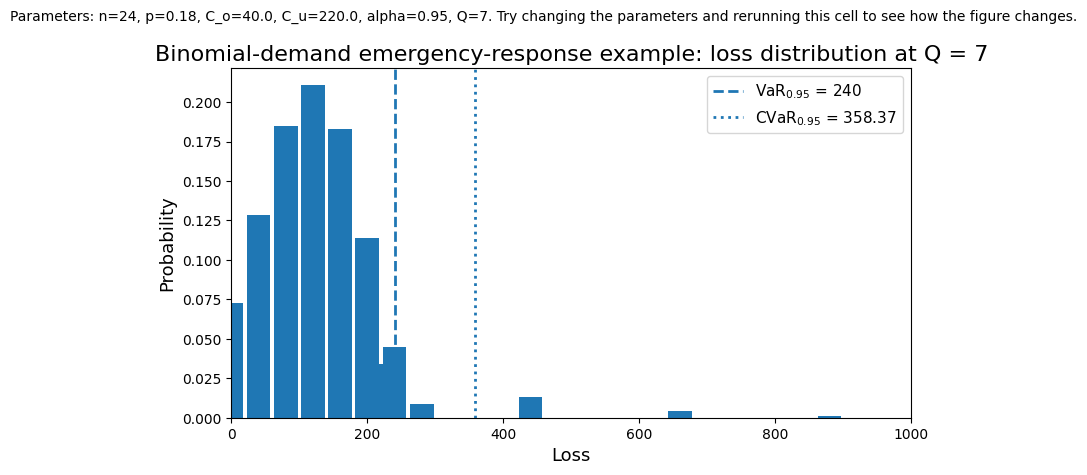

In [25]:

Q_rep_binom = 7
losses_b, probs_b = induced_loss_distribution(Q_rep_binom, d_binom, p_binom_support, Co_binom, Cu_binom)
var_b = discrete_var(losses_b, probs_b, alpha_binom)
cvar_b = discrete_cvar(losses_b, probs_b, alpha_binom)

show_parameters(
    "Figure parameters: binomial loss distribution",
    {
        "n": n_binom,
        "p": p_binom,
        "C_o": Co_binom,
        "C_u": Cu_binom,
        "alpha": alpha_binom,
        "Representative Q": Q_rep_binom,
        "x-axis max": 1000,
    },
)

plt.figure()
plt.bar(losses_b, probs_b, width=35)
plt.axvline(var_b, linestyle="--", label=fr"VaR$_{{{alpha_binom:.2f}}}$ = {var_b:.0f}")
plt.axvline(cvar_b, linestyle=":", label=fr"CVaR$_{{{alpha_binom:.2f}}}$ = {cvar_b:.2f}")
plt.xlim(0, 1000)
plt.xlabel("Loss")
plt.ylabel("Probability")
plt.title(f"Binomial-demand emergency-response example: loss distribution at Q = {Q_rep_binom}")
plt.suptitle(plot_note(
    {
        "n": n_binom,
        "p": p_binom,
        "C_o": Co_binom,
        "C_u": Cu_binom,
        "alpha": alpha_binom,
        "Q": Q_rep_binom,
    }
), y=0.98, fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_1_binomial_distribution_xmax1000.png", dpi=220, bbox_inches="tight")
plt.show()


### 2E. Mean--CVaR objective as a function of Q

### Figure parameters: binomial objective vs Q

- **n** = `24`
- **p** = `0.18`
- **C_o** = `40.0`
- **C_u** = `220.0`
- **alpha** = `0.95`
- **lambda** = `0.6`
- **Q range** = `[0, 24]`

*Try changing these values and rerunning the downstream cells to see how the results change.*

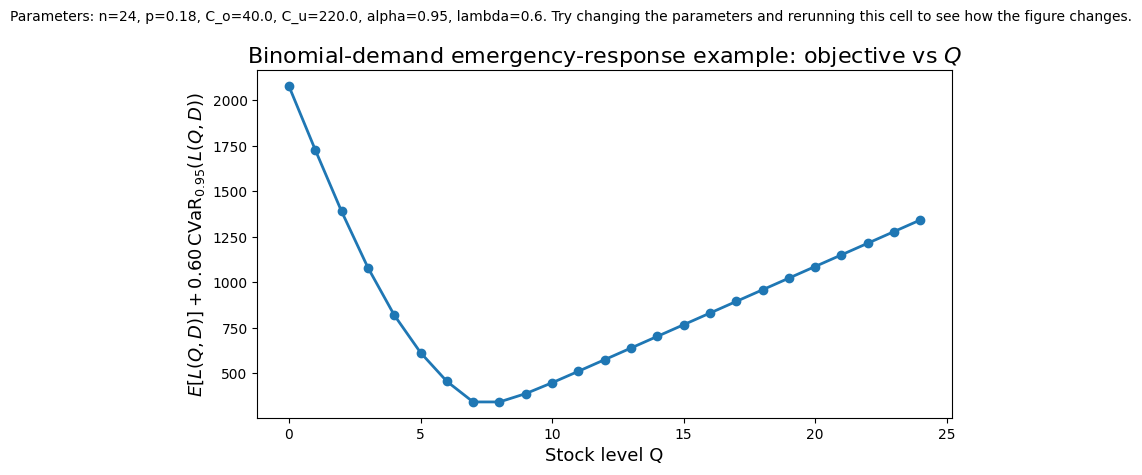

7

In [26]:

obj_binom = [
    objective_mean_cvar(Q, d_binom, p_binom_support, Co_binom, Cu_binom, alpha_binom, lambda_binom)
    for Q in Q_values_binom
]

show_parameters(
    "Figure parameters: binomial objective vs Q",
    {
        "n": n_binom,
        "p": p_binom,
        "C_o": Co_binom,
        "C_u": Cu_binom,
        "alpha": alpha_binom,
        "lambda": lambda_binom,
        "Q range": [int(Q_values_binom.min()), int(Q_values_binom.max())],
    },
)

plt.figure()
plt.plot(Q_values_binom, obj_binom, marker="o")
plt.xlabel("Stock level Q")
plt.ylabel(fr"$E[L(Q,D)] + {lambda_binom:.2f}\,\mathrm{{CVaR}}_{{{alpha_binom:.2f}}}(L(Q,D))$")
plt.title(fr"Binomial-demand emergency-response example: objective vs $Q$")
plt.suptitle(plot_note(
    {
        "n": n_binom,
        "p": p_binom,
        "C_o": Co_binom,
        "C_u": Cu_binom,
        "alpha": alpha_binom,
        "lambda": lambda_binom,
    }
), y=0.98, fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "binomial_objective_vs_Q.png", dpi=220, bbox_inches="tight")
plt.show()

Q_star_binom = int(Q_values_binom[np.argmin(obj_binom)])
Q_star_binom


### 2F. Optimal stock level as a function of lambda

### Figure parameters: binomial optimal Q as a function of lambda

- **n** = `24`
- **p** = `0.18`
- **C_o** = `40.0`
- **C_u** = `220.0`
- **alpha fixed** = `0.95`
- **lambda range** = `[0.0, 2.0]`

*Try changing these values and rerunning the downstream cells to see how the results change.*

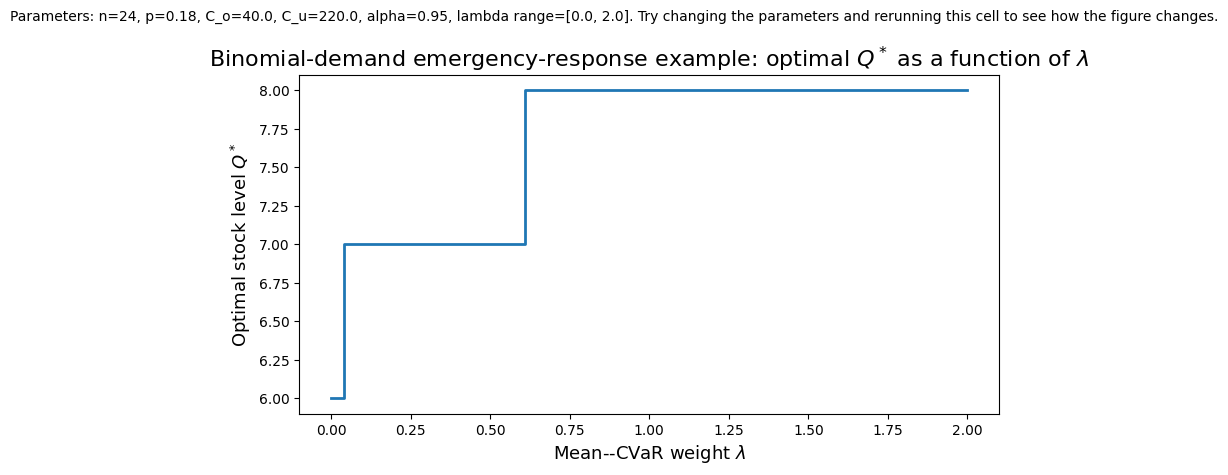

In [27]:

lambda_grid_binom = np.linspace(0, 2.0, 201)
Qstar_lambda_binom = []

for lam in lambda_grid_binom:
    vals = [
        objective_mean_cvar(Q, d_binom, p_binom_support, Co_binom, Cu_binom, alpha_binom, lam)
        for Q in Q_values_binom
    ]
    Qstar_lambda_binom.append(int(Q_values_binom[np.argmin(vals)]))

show_parameters(
    "Figure parameters: binomial optimal Q as a function of lambda",
    {
        "n": n_binom,
        "p": p_binom,
        "C_o": Co_binom,
        "C_u": Cu_binom,
        "alpha fixed": alpha_binom,
        "lambda range": "[0.0, 2.0]",
    },
)

plt.figure()
plt.step(lambda_grid_binom, Qstar_lambda_binom, where="post")
plt.xlabel(r"Mean--CVaR weight $\lambda$")
plt.ylabel(r"Optimal stock level $Q^*$")
plt.title(r"Binomial-demand emergency-response example: optimal $Q^*$ as a function of $\lambda$")
plt.suptitle(plot_note(
    {
        "n": n_binom,
        "p": p_binom,
        "C_o": Co_binom,
        "C_u": Cu_binom,
        "alpha": alpha_binom,
        "lambda range": "[0.0, 2.0]",
    }
), y=0.98, fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "binomial_Qstar_vs_lambda.png", dpi=220, bbox_inches="tight")
plt.show()


### 2G. Optimal stock level as a function of alpha

### Figure parameters: binomial optimal Q as a function of alpha

- **n** = `24`
- **p** = `0.18`
- **C_o** = `40.0`
- **C_u** = `220.0`
- **lambda fixed** = `0.6`
- **alpha range** = `[0.80, 0.995]`

*Try changing these values and rerunning the downstream cells to see how the results change.*

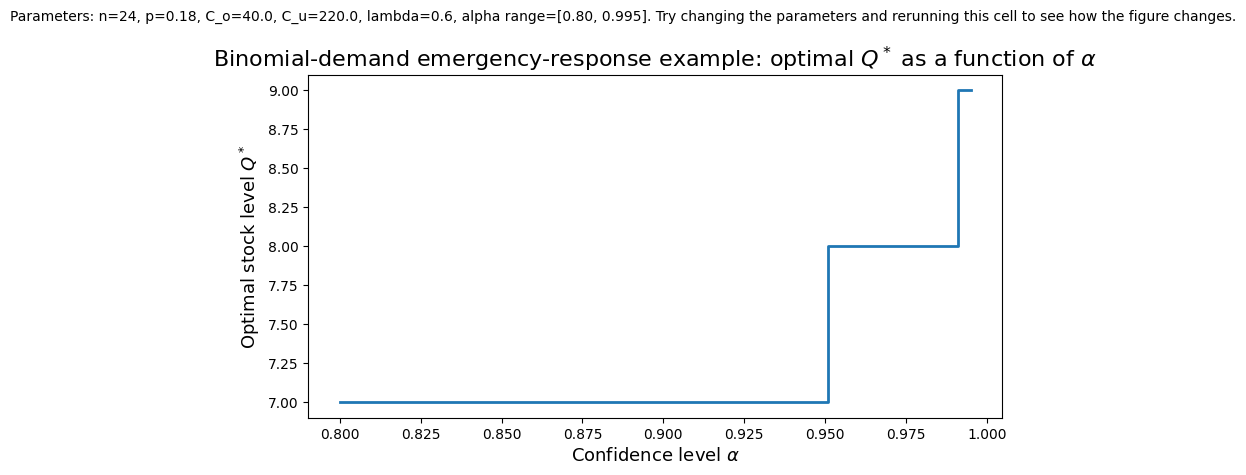

In [29]:

alpha_grid_binom = np.linspace(0.80, 0.995, 196)
Qstar_alpha_binom = []

for alpha in alpha_grid_binom:
    vals = [
        objective_mean_cvar(Q, d_binom, p_binom_support, Co_binom, Cu_binom, alpha, lambda_binom)
        for Q in Q_values_binom
    ]
    Qstar_alpha_binom.append(int(Q_values_binom[np.argmin(vals)]))

show_parameters(
    "Figure parameters: binomial optimal Q as a function of alpha",
    {
        "n": n_binom,
        "p": p_binom,
        "C_o": Co_binom,
        "C_u": Cu_binom,
        "lambda fixed": lambda_binom,
        "alpha range": "[0.80, 0.995]",
    },
)

plt.figure()
plt.step(alpha_grid_binom, Qstar_alpha_binom, where="post")
plt.xlabel(r"Confidence level $\alpha$")
plt.ylabel(r"Optimal stock level $Q^*$")
plt.title(r"Binomial-demand emergency-response example: optimal $Q^*$ as a function of $\alpha$")
plt.suptitle(
    plot_note(
        {
            "n": n_binom,
            "p": p_binom,
            "C_o": Co_binom,
            "C_u": Cu_binom,
            "lambda": lambda_binom,
            "alpha range": "[0.80, 0.995]",
        }
    ),
    y=0.98,
    fontsize=10,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "binomial_Qstar_vs_alpha.png", dpi=220, bbox_inches="tight")
plt.show()



## 3. Poisson-demand newsvendor example: backup portable generators

The second worked example concerns municipal emergency depots that stock backup portable generators for outage-related incidents during a storm season.

The chapter uses:
- demand $D \sim \mathrm{Pois}(5.2)$,
- overage cost $C_o = 90$,
- underage cost $C_u = 520$.

This setup is intentionally different from the binomial case. The support of demand is unbounded, so the upper tail can remain influential far above the mean.


### 3A. Parameters

In [30]:

mu_pois = 5.2
Co_pois = 90.0
Cu_pois = 520.0

alpha_pois = 0.95
lambda_pois = 0.5
Q_values_pois = np.arange(0, 16)


### 3B. Summary table for selected stock levels

In [31]:

d_pois, p_pois_support = poisson_support_probs(mu_pois)

show_parameters(
    "Poisson table parameters",
    {
        "mu": mu_pois,
        "C_o": Co_pois,
        "C_u": Cu_pois,
        "alpha": alpha_pois,
        "lambda": lambda_pois,
        "Q values shown": [7, 8, 9],
    },
)

pois_rows = []
for Q in [7, 8, 9]:
    losses, probs = induced_loss_distribution(Q, d_pois, p_pois_support, Co_pois, Cu_pois)
    mean_loss = expected_loss_from_distribution(Q, d_pois, p_pois_support, Co_pois, Cu_pois)
    var = discrete_var(losses, probs, alpha_pois)
    tce = discrete_tce(losses, probs, alpha_pois)
    cvar = discrete_cvar(losses, probs, alpha_pois)
    obj = mean_loss + lambda_pois * cvar
    pois_rows.append({
        "Q": Q,
        "E[L(Q,D)]": mean_loss,
        make_tail_column_name("VaR", alpha_pois): var,
        make_tail_column_name("TCE", alpha_pois): tce,
        make_tail_column_name("CVaR", alpha_pois): cvar,
        "E[L]+lambda*CVaR": obj,
    })

pois_table = pd.DataFrame(pois_rows)
pois_table.round(2)


### Poisson table parameters

- **mu** = `5.2`
- **C_o** = `90.0`
- **C_u** = `520.0`
- **alpha** = `0.95`
- **lambda** = `0.5`
- **Q values shown** = `[7, 8, 9]`

*Try changing these values and rerunning the downstream cells to see how the results change.*

,Q,"E[L(Q,D)]",VaR_0.95,TCE_0.95,CVaR_0.95,E[L]+lambda*CVaR
0,7,348.66,1040.0,1477.86,1757.52,1227.42
1,8,344.07,630.0,1063.26,1270.17,979.15
2,9,384.09,720.0,955.10,964.04,866.11


### 3C. Distribution plot at the representative stock level

### Figure parameters: Poisson loss distribution

- **mu** = `5.2`
- **C_o** = `90.0`
- **C_u** = `520.0`
- **alpha** = `0.95`
- **Representative Q** = `8`
- **x-axis max** = `2000`

*Try changing these values and rerunning the downstream cells to see how the results change.*

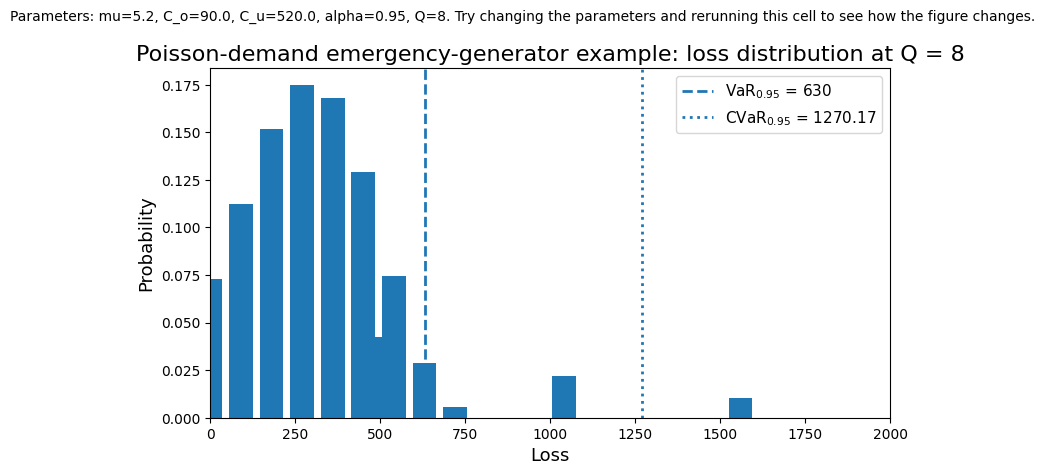

In [32]:

Q_rep_pois = 8
losses_p, probs_p = induced_loss_distribution(Q_rep_pois, d_pois, p_pois_support, Co_pois, Cu_pois)
var_p = discrete_var(losses_p, probs_p, alpha_pois)
cvar_p = discrete_cvar(losses_p, probs_p, alpha_pois)

show_parameters(
    "Figure parameters: Poisson loss distribution",
    {
        "mu": mu_pois,
        "C_o": Co_pois,
        "C_u": Cu_pois,
        "alpha": alpha_pois,
        "Representative Q": Q_rep_pois,
        "x-axis max": 2000,
    },
)

plt.figure()
plt.bar(losses_p, probs_p, width=70)
plt.axvline(var_p, linestyle="--", label=fr"VaR$_{{{alpha_pois:.2f}}}$ = {var_p:.0f}")
plt.axvline(cvar_p, linestyle=":", label=fr"CVaR$_{{{alpha_pois:.2f}}}$ = {cvar_p:.2f}")
plt.xlim(0, 2000)
plt.xlabel("Loss")
plt.ylabel("Probability")
plt.title(f"Poisson-demand emergency-generator example: loss distribution at Q = {Q_rep_pois}")
plt.suptitle(plot_note(
    {
        "mu": mu_pois,
        "C_o": Co_pois,
        "C_u": Cu_pois,
        "alpha": alpha_pois,
        "Q": Q_rep_pois,
    }
), y=0.98, fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_5_poisson_distribution_xmax2000.png", dpi=220, bbox_inches="tight")
plt.show()


### 3D. Mean--CVaR objective as a function of Q

### Figure parameters: Poisson objective vs Q

- **mu** = `5.2`
- **C_o** = `90.0`
- **C_u** = `520.0`
- **alpha** = `0.95`
- **lambda** = `0.5`
- **Q range** = `[0, 15]`

*Try changing these values and rerunning the downstream cells to see how the results change.*

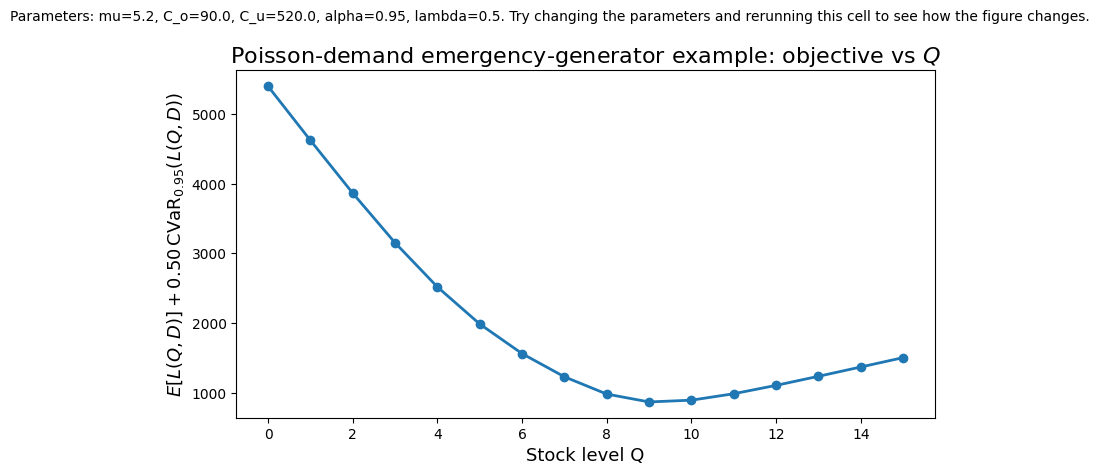

9

In [33]:

obj_pois = [
    objective_mean_cvar(Q, d_pois, p_pois_support, Co_pois, Cu_pois, alpha_pois, lambda_pois)
    for Q in Q_values_pois
]

show_parameters(
    "Figure parameters: Poisson objective vs Q",
    {
        "mu": mu_pois,
        "C_o": Co_pois,
        "C_u": Cu_pois,
        "alpha": alpha_pois,
        "lambda": lambda_pois,
        "Q range": [int(Q_values_pois.min()), int(Q_values_pois.max())],
    },
)

plt.figure()
plt.plot(Q_values_pois, obj_pois, marker="o")
plt.xlabel("Stock level Q")
plt.ylabel(fr"$E[L(Q,D)] + {lambda_pois:.2f}\,\mathrm{{CVaR}}_{{{alpha_pois:.2f}}}(L(Q,D))$")
plt.title(fr"Poisson-demand emergency-generator example: objective vs $Q$")
plt.suptitle(plot_note(
    {
        "mu": mu_pois,
        "C_o": Co_pois,
        "C_u": Cu_pois,
        "alpha": alpha_pois,
        "lambda": lambda_pois,
    }
), y=0.98, fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "poisson_new_objective_vs_Q.png", dpi=220, bbox_inches="tight")
plt.show()

Q_star_pois = int(Q_values_pois[np.argmin(obj_pois)])
Q_star_pois


### 3E. Optimal stock level as a function of lambda

### Figure parameters: Poisson optimal Q as a function of lambda

- **mu** = `5.2`
- **C_o** = `90.0`
- **C_u** = `520.0`
- **alpha fixed** = `0.95`
- **lambda range** = `[0.0, 2.0]`

*Try changing these values and rerunning the downstream cells to see how the results change.*

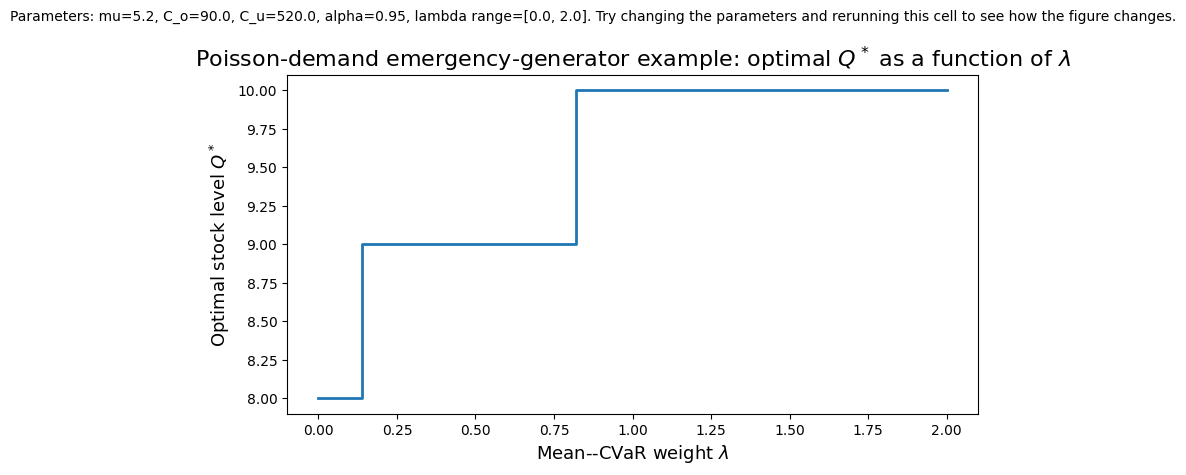

In [34]:

lambda_grid_pois = np.linspace(0, 2.0, 201)
Qstar_lambda_pois = []

for lam in lambda_grid_pois:
    vals = [
        objective_mean_cvar(Q, d_pois, p_pois_support, Co_pois, Cu_pois, alpha_pois, lam)
        for Q in Q_values_pois
    ]
    Qstar_lambda_pois.append(int(Q_values_pois[np.argmin(vals)]))

show_parameters(
    "Figure parameters: Poisson optimal Q as a function of lambda",
    {
        "mu": mu_pois,
        "C_o": Co_pois,
        "C_u": Cu_pois,
        "alpha fixed": alpha_pois,
        "lambda range": "[0.0, 2.0]",
    },
)

plt.figure()
plt.step(lambda_grid_pois, Qstar_lambda_pois, where="post")
plt.xlabel(r"Mean--CVaR weight $\lambda$")
plt.ylabel(r"Optimal stock level $Q^*$")
plt.title(r"Poisson-demand emergency-generator example: optimal $Q^*$ as a function of $\lambda$")
plt.suptitle(plot_note(
    {
        "mu": mu_pois,
        "C_o": Co_pois,
        "C_u": Cu_pois,
        "alpha": alpha_pois,
        "lambda range": "[0.0, 2.0]",
    }
), y=0.98, fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "poisson_new_Qstar_vs_lambda.png", dpi=220, bbox_inches="tight")
plt.show()


### 3F. Optimal stock level as a function of alpha

### Figure parameters: Poisson optimal Q as a function of alpha

- **mu** = `5.2`
- **C_o** = `90.0`
- **C_u** = `520.0`
- **lambda fixed** = `0.5`
- **alpha range** = `[0.80, 0.995]`

*Try changing these values and rerunning the downstream cells to see how the results change.*

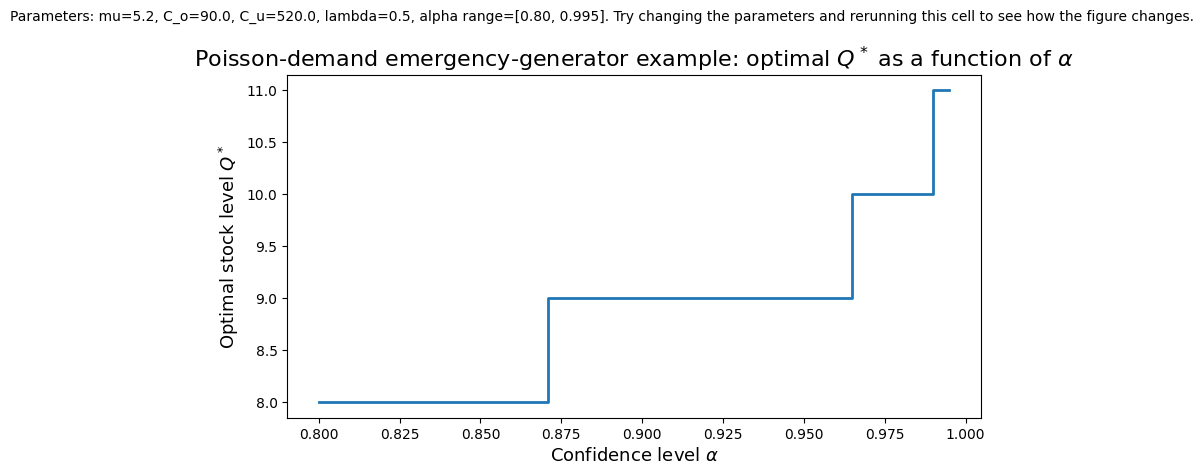

In [36]:

alpha_grid_pois = np.linspace(0.80, 0.995, 196)
Qstar_alpha_pois = []

for alpha in alpha_grid_pois:
    vals = [
        objective_mean_cvar(Q, d_pois, p_pois_support, Co_pois, Cu_pois, alpha, lambda_pois)
        for Q in Q_values_pois
    ]
    Qstar_alpha_pois.append(int(Q_values_pois[np.argmin(vals)]))

show_parameters(
    "Figure parameters: Poisson optimal Q as a function of alpha",
    {
        "mu": mu_pois,
        "C_o": Co_pois,
        "C_u": Cu_pois,
        "lambda fixed": lambda_pois,
        "alpha range": "[0.80, 0.995]",
    },
)

plt.figure()
plt.step(alpha_grid_pois, Qstar_alpha_pois, where="post")
plt.xlabel(r"Confidence level $\alpha$")
plt.ylabel(r"Optimal stock level $Q^*$")
plt.title(r"Poisson-demand emergency-generator example: optimal $Q^*$ as a function of $\alpha$")
plt.suptitle(
    plot_note(
        {
            "mu": mu_pois,
            "C_o": Co_pois,
            "C_u": Cu_pois,
            "lambda": lambda_pois,
            "alpha range": "[0.80, 0.995]",
        }
    ),
    y=0.98,
    fontsize=10,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "poisson_new_Qstar_vs_alpha.png", dpi=220, bbox_inches="tight")
plt.show()



## 4. Comparing the two discrete-demand settings

The chapter’s central contrast is that the binomial model has **bounded support** while the Poisson model has **unbounded support**.

This matters directly for tail-sensitive decision making:
- the binomial case protects against concentrated but capped surges,
- the Poisson case protects against rare but open-ended shortage episodes.


In [37]:

comparison = pd.DataFrame([
    {
        "Feature": "Demand support",
        "Binomial case": "Bounded",
        "Poisson case": "Unbounded",
    },
    {
        "Feature": "Tail type",
        "Binomial case": "Severe but finite",
        "Poisson case": "Open-ended",
    },
    {
        "Feature": "Typical interpretation",
        "Binomial case": "Fixed opportunities",
        "Poisson case": "Rare arrivals over time",
    },
    {
        "Feature": "Effect on CVaR",
        "Binomial case": "Tail capped by support",
        "Poisson case": "Tail can remain influential far above the mean",
    },
])
comparison


,Feature,Binomial case,Poisson case
0,Demand support,Bounded,Unbounded
1,Tail type,Severe but finite,Open-ended
2,Typical interpretation,Fixed opportunities,Rare arrivals over time
3,Effect on CVaR,Tail capped by support,Tail can remain influential far above the mean



## 5. Key takeaway table

This final table collects the main numerical outputs used in the chapter.


In [38]:

key_takeaways = pd.concat(
    [
        binom_table.assign(example="Binomial: drone kits"),
        pois_table.assign(example="Poisson: generators"),
    ],
    ignore_index=True,
)

cols = ["example", "Q", "E[L(Q,D)]", "VaR_0.95", "TCE_0.95", "CVaR_0.95", "E[L]+lambda*CVaR"]
key_takeaways[cols].round(2)


,example,Q,"E[L(Q,D)]",VaR_0.95,TCE_0.95,CVaR_0.95,E[L]+lambda*CVaR
0,Binomial: drone kits,5,146.79,660.0,772.42,779.19,614.30
1,Binomial: drone kits,7,128.03,240.0,321.43,358.37,343.05
2,Binomial: drone kits,9,189.27,320.0,331.40,332.57,388.81
3,Poisson: generators,7,348.66,1040.0,1477.86,1757.52,1227.42
4,Poisson: generators,8,344.07,630.0,1063.26,1270.17,979.15
5,Poisson: generators,9,384.09,720.0,955.10,964.04,866.11



## 6. Notes

- The notebook computes **exact discrete VaR, TCE, and CVaR** from the induced loss distribution.
- The Poisson support is truncated numerically at an extremely high quantile and then renormalized; for the present parameter values this has negligible effect on the results.
- The generated figures are saved into `figures/chapter_5/` using the filenames referenced in the chapter text.
